# NLP Emotion Recognition using HuggingFace and Fine-tuning DistillBERT

In [1]:
!pip install --upgrade transformers
!pip install datasets
!pip install bertviz
!pip install umap-learn
!pip install huggingface_hub

In [2]:
import pandas as pd
import numpy as np

from huggingface_hub import list_datasets
# list_datasets gives us all the datasets from hugging face

In [3]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
dataset.set_format(type="pandas")

In [6]:
dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [7]:
df = dataset["train"][:]

In [8]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [9]:
dataset["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

In [10]:
classes = dataset["train"].features["label"].names

In [11]:
classes

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [12]:
df["label_name"] = df["label"].apply(lambda x: classes[x])

In [13]:
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


# Data Analysis

In [14]:
import matplotlib.pyplot as plt


In [15]:
df["label_name"].value_counts()

,count
label_name,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label_name'>

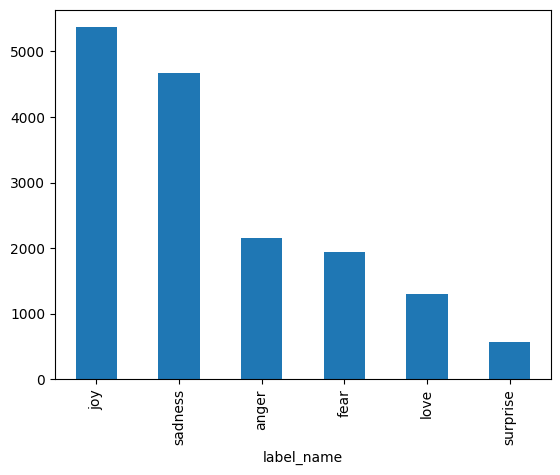

In [16]:
df["label_name"].value_counts().plot(kind="bar")

In [17]:
df["words per tweet"] = df["text"].str.split().apply(len)

<Axes: title={'center': 'words per tweet'}, xlabel='label_name'>

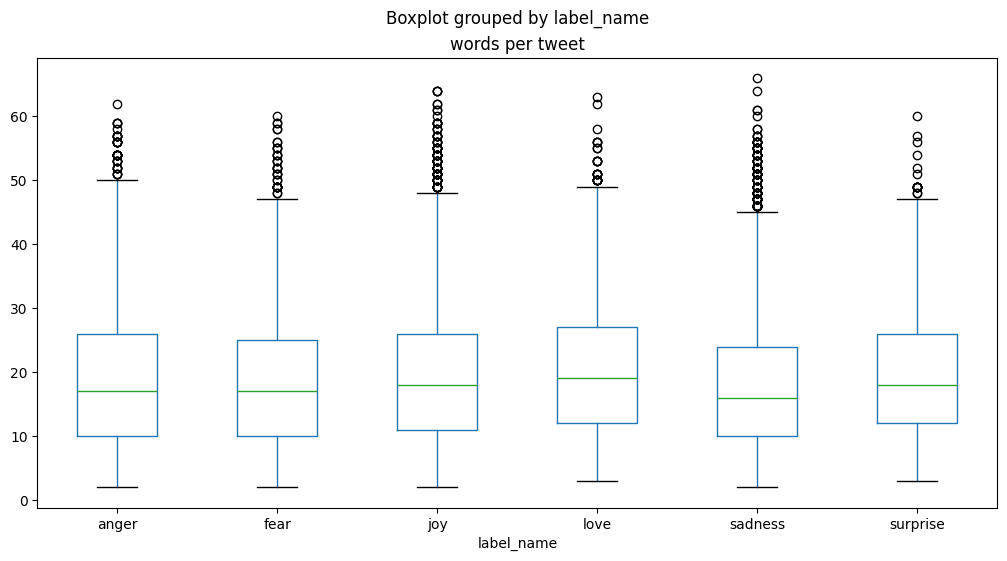

In [18]:
df.boxplot(["words per tweet"], by="label_name", grid=False, figsize=(12,6))

In [19]:
from transformers import AutoTokenizer

model_ckpt = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [20]:
text = "I love Aalo paratha. I m using Hugging face"
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 1045, 2293, 9779, 4135, 11498, 8322, 1012, 1045, 1049, 2478, 17662, 2227, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


the first and last tokens are special tokens the first one is known as cls(indicates start of a sentence) and second one is known as separetor token(indicates end of a sentence)

In [21]:
token = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)

print(token)


['[CLS]', 'i', 'love', 'aa', '##lo', 'para', '##tha', '.', 'i', 'm', 'using', 'hugging', 'face', '[SEP]']


In [22]:
tokenizer.vocab_size, tokenizer.model_max_length

(30522, 512)

# Tokenization of  emotion dataset

In [23]:
dataset.reset_format() #now the padas type is removed

In [24]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncation=True)

In [25]:
print(tokenize(dataset["train"][:5]))

{'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102], [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1045, 2572, 2412, 3110, 16839, 9080, 12863, 2055, 1996, 13788, 1045, 2097, 2113, 2008, 2009, 2003, 2145, 2006, 1996, 3200, 102, 0], [101, 1045, 2572, 3110, 24665, 7140, 11714, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1,

In [26]:
dataset_encoded = dataset.map(tokenize, batched=True, batch_size=None)

In [27]:
dataset_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

## sample model

In [28]:
text

'I love Aalo paratha. I m using Hugging face'

In [29]:
inputs = tokenizer(text, return_tensors="pt")


In [30]:
inputs

{'input_ids': tensor([[  101,  1045,  2293,  9779,  4135, 11498,  8322,  1012,  1045,  1049,
          2478, 17662,  2227,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [31]:
from transformers import AutoModel
import torch

model = AutoModel.from_pretrained(model_ckpt)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [32]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [33]:
with torch.no_grad():
  outputs = model(**inputs)

last_hidden_states = outputs.last_hidden_state

In [34]:
last_hidden_states

tensor([[[-5.5131e-02,  8.2532e-03,  8.0912e-02,  ..., -2.3498e-01,
           3.8432e-01,  2.8146e-01],
         [ 3.1387e-01,  1.3838e-01, -8.9679e-02,  ..., -6.1907e-02,
           7.1932e-01,  3.4900e-01],
         [ 7.2123e-01,  4.8530e-01,  9.1744e-01,  ..., -3.0141e-01,
           2.8995e-01,  1.0926e-01],
         ...,
         [-2.2354e-01,  8.8633e-02,  5.0966e-01,  ..., -1.6518e-01,
           1.2135e-01,  2.0147e-01],
         [-9.8097e-02,  4.0195e-02,  2.4521e-01,  ..., -1.3287e-01,
          -5.9747e-04,  5.6649e-02],
         [ 7.5612e-01,  2.8171e-01, -7.9821e-02,  ...,  1.2555e-01,
          -3.2654e-01, -4.7838e-01]]])

In [35]:
last_hidden_states.shape

torch.Size([1, 14, 768])

In [37]:
from transformers import AutoModelForSequenceClassification

num_labels =len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
from transformers import TrainingArguments


In [43]:
batch_size = 64
model_name = "distillbert-finetuned-emotion"

trauning_args = TrainingArguments(
    output_dir = model_name,
    num_train_epochs = 2,
    learning_rate = 2e-5,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    weight_decay = 0.01,
    push_to_hub = False,
    disable_tqdm = False
    )

In [44]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average="weighted")
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

In [45]:
from transformers import Trainer

In [47]:
trainer = Trainer(
    model = model,
    args = trauning_args,
    compute_metrics = compute_metrics,
    train_dataset = dataset_encoded["train"],
    eval_dataset = dataset_encoded["validation"]
)

In [48]:
trainer.train()

Step,Training Loss
500,0.517135


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.5171348266601562, metrics={'train_runtime': 240.1007, 'train_samples_per_second': 133.277, 'train_steps_per_second': 2.082, 'total_flos': 720342861696000.0, 'train_loss': 0.5171348266601562, 'epoch': 2.0})

In [50]:
pred_output = trainer.predict(dataset_encoded["test"])

pred_output.metrics

{'test_loss': 0.2066703736782074,
 'test_accuracy': 0.9185,
 'test_f1': 0.9178700751294931,
 'test_runtime': 3.9497,
 'test_samples_per_second': 506.363,
 'test_steps_per_second': 8.102}

In [62]:
# for prediction

text ="i hellllllooo"

input_encoded = tokenizer(text, return_tensors="pt").to(device)
with torch.no_grad():
  output = model(**input_encoded)
output

SequenceClassifierOutput(loss=None, logits=tensor([[ 1.1097,  0.8306, -0.9495,  0.6036, -0.0853, -1.0035]],
       device='cuda:0'), hidden_states=None, attentions=None)

In [63]:
logits = output.logits
pred = torch.argmax(logits,dim=1).item()
pred, classes[pred]

(0, 'sadness')